In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

zip_path = '/content/drive/MyDrive/Yelp-Photos.zip'
extract_path = '/content/yelp_photos'


Mounted at /content/drive


In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
import tarfile

tar_path = os.path.join(extract_path, 'Yelp Photos/yelp_photos.tar')
image_extract_path = '/content/yelp_images'

with tarfile.open(tar_path, 'r') as tar_ref:
    tar_ref.extractall(image_extract_path)


In [ ]:
import pandas as pd

json_path = os.path.join(image_extract_path, 'photos.json')
df = pd.read_json(json_path, lines=True)

target_labels = ['food', 'drink', 'menu', 'inside']
df_filtered = df[df['label'].isin(target_labels)]

df_sampled = df_filtered.groupby('label').apply(lambda x: x.sample(n=1250, random_state=42)).reset_index(drop=True)

print("Total images selected:", len(df_sampled))


Total images selected: 5000


<ipython-input-4-1a825693c33e>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_filtered.groupby('label').apply(lambda x: x.sample(n=1250, random_state=42)).reset_index(drop=True)


In [ ]:
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 64
image_dir = os.path.join(image_extract_path, 'photos')
X = []
y = []

for idx, row in tqdm(df_sampled.iterrows(), total=len(df_sampled)):
    img_id = row['photo_id']
    label = row['label']
    img_path = os.path.join(image_dir, img_id + '.jpg')

    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X.append(img.flatten())
        y.append(label)
    except:
        continue

X = np.array(X)
y = np.array(y)

print("Loaded images:", X.shape[0])
print("Feature shape per image:", X.shape[1])


100%|██████████| 5000/5000 [00:26<00:00, 191.97it/s]


Loaded images: 4996
Feature shape per image: 12288


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200, random_state=42)
X_pca = pca.fit_transform(X)
print("PCA-reduced shape:", X_pca.shape)


PCA-reduced shape: (4996, 200)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model training completed.")


SVM model training completed.


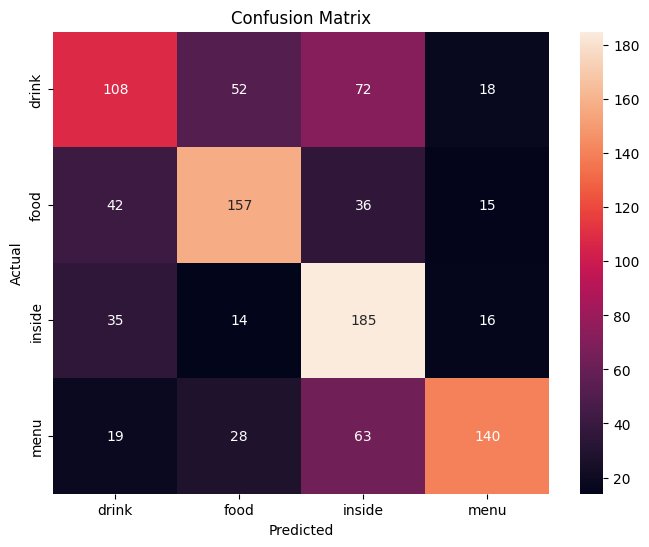

              precision    recall  f1-score   support

       drink       0.53      0.43      0.48       250
        food       0.63      0.63      0.63       250
      inside       0.52      0.74      0.61       250
        menu       0.74      0.56      0.64       250

    accuracy                           0.59      1000
   macro avg       0.60      0.59      0.59      1000
weighted avg       0.60      0.59      0.59      1000

Macro-Averaged AUC Score: 0.8286


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
print("Macro-Averaged AUC Score:", round(auc, 4))
